# Justiniano, Primiceri and Tambalotti (2009) — DSGE Model

**Reference:** Justiniano, A., Primiceri, G. E., & Tambalotti, A. (2010). *Investment shocks and business cycles*. Journal of Monetary Economics, 57(2), 132–145.  
Working paper version: NBER Working Paper 15739 (2009).

---

## Model Overview

The JPT model is a medium-scale New Keynesian DSGE model estimated on U.S. quarterly data. It extends the Smets-Wouters (2007) framework with a central focus on **investment-specific technology (IST) shocks** — disturbances to the marginal efficiency of investment — as a key driver of business cycles.

### Key features
- **Households** face habit formation in consumption and supply differentiated labor to unions that set wages subject to Calvo-style staggering and partial indexation.
- **Firms** use capital and labor to produce intermediate goods under monopolistic competition, with Calvo price-setting and partial inflation indexation.
- **Capital** is produced by capital-goods firms subject to investment adjustment costs, and its utilization rate is chosen by households at a convex cost.
- **Seven structural shocks:** neutral technology growth, investment-specific technology, monetary policy, government spending, price markup, wage markup, and intertemporal preference.
- **Monetary policy** follows a generalized Taylor rule with interest-rate smoothing and responses to the inflation rate, the output gap, and the change in the output gap.

The paper's main finding is that **investment shocks explain the bulk of business-cycle fluctuations** in output and hours, whereas neutral technology shocks are less important than previously thought.

---

### Notebook structure
1. Gensys solver (inline)
2. Model parameters
3. JPT model in Gensys canonical form and solution
4. Impulse-response functions
5. Plotting utilities
6. Example: comparison across parameter configurations

## Prerequisites

This notebook requires the following Julia packages. Install them once with:

```julia
using Pkg
Pkg.add(["Parameters", "LinearAlgebra", "Plots"])
```

- **Parameters.jl** — provides `@with_kw` and `@unpack` macros for convenient struct handling.
- **LinearAlgebra** — standard library; provides `schur!`, `svd!`, `diagm`, `I`, etc.
- **Plots.jl** — plotting; we use the PyPlot backend for publication-quality figures.

The Gensys solver (Chris Sims, 2002) is included **inline** in the next cell — no external file is needed.

## 1. Gensys: Rational Expectations Solver

**Gensys** (Sims, 2002, *Solving Linear Rational Expectations Models*, Computational Economics) is the standard algorithm for solving linear rational expectations (LRE) models.

### The canonical form

Any LRE model can be written as:

$$\Gamma_0 \, x_t = \Gamma_1 \, x_{t-1} + C + \Psi \, \varepsilon_t + \Pi \, \eta_t$$

where:
- $x_t$ is the vector of **endogenous state variables** (including expectational and lagged variables),
- $\varepsilon_t \sim N(0, I)$ are the **exogenous structural shocks**,
- $\eta_t$ are the **expectational errors** (i.e., $\eta_t = x_t - E_{t-1}[x_t]$), which Gensys determines endogenously,
- $C$ is a vector of constants (capturing the non-stochastic steady state if the system is written in deviations from it, but here used to store the mean of observables).

### What Gensys does

Gensys applies a **generalized Schur (QZ) decomposition** to the matrix pencil $(\Gamma_0, \Gamma_1)$:

$$\Gamma_0 = Q' S Z', \quad \Gamma_1 = Q' T Z'$$

The eigenvalues of the pencil are the ratios $\lambda_i = T_{ii} / S_{ii}$ (the generalized eigenvalues). Gensys **reorders** the decomposition so that:
- **Stable eigenvalues** ($|\lambda_i| < 1$) come first — these correspond to predetermined (backward-looking) variables.
- **Unstable eigenvalues** ($|\lambda_i| \geq 1$) come last — these correspond to forward-looking (jump) variables, whose explosive paths must be ruled out by choosing $\eta_t$ appropriately.

By imposing the **Blanchard-Kahn conditions** — that the number of unstable eigenvalues equals the number of expectational errors — Gensys pins down the unique (or non-unique) stable solution and returns the **reduced-form state-space**:

$$x_t = G_1 \, x_{t-1} + \text{impact} \cdot \varepsilon_t$$

The `eu` vector returned by Gensys encodes existence (`eu[1]=1`) and uniqueness (`eu[2]=1`) of the solution.

The implementation below is a Julia port of Sims' original MATLAB code, using `LinearAlgebra.schur!` for the generalized Schur decomposition.

In [1]:
using LinearAlgebra

let

    A_mul_Bc(a,b) = a*ctranspose(b)
    Ac_mul_B(a,b) = ctranspose(a)*b
    ctranspose(x) = conj(transpose(x))
    ep = sqrt(eps()) * 10 #machine epsilon

    function gensysdt(Γ0, Γ1, c, Ψ, Π, args...)
        F = schur!(complex(Γ0), complex(Γ1))
        gensysdt(F, c, Ψ, Π, args...)
    end

    function gensysdt(F::LinearAlgebra.GeneralizedSchur, c, Ψ, Π)
        gensysdt(F, c, Ψ, Π, new_div(F))
    end

    function gensysdt(F::LinearAlgebra.GeneralizedSchur, c, Ψ, Π, divv)

        eu = [0, 0]
        a, b = F.S , F.T
        n = size(a, 1)

        for i in 1:n
            if (abs(a[i, i]) < ep) && (abs(b[i, i]) < ep)
                @info("Coincident zeros.  Indeterminacy and/or nonexistence.")
                eu = [-2, -2]
                G1 = Array{Float64, 2}() ;  C = Array{Float64, 1}() ; impact = Array{Float64, 2}() ; fmat = Array{Complex{Float64}, 2}() ; fwt = Array{Complex{Float64}, 2}() ; ywt = Vector{Complex{Float64}}() ; gev = Vector{Complex{Float64}}() ; loose = Array{Float64, 2}()
                return G1, C, impact, fmat, fwt, ywt, gev, eu, loose
            end
        end

        movelast = Bool[abs(b[i, i]) > divv * abs(a[i, i]) for i in 1:n]
        nunstab = sum(movelast)
        FS = ordschur!(F, (!).(movelast))
        a, b, qt, z = FS.S, FS.T, FS.Q, FS.Z

        gev = hcat(diag(a), diag(b))
        qt1 = qt[:, 1:(n - nunstab)]
        qt2 = qt[:, (n - nunstab + 1):n]
        etawt = Ac_mul_B(qt2, Π)
        neta = size(Π, 2)

        if nunstab == 0
            etawt = zeros(0, neta)
            ueta = zeros(0, 0)
            deta = zeros(0, 0)
            veta = zeros(neta, 0)
            bigev = 0
        else
            bigev, ueta, deta, veta = decomposition_svd!(etawt)
        end

        eu[1] = length(bigev) >= nunstab

        if nunstab == n
            etawt1 = zeros(0, neta)
            bigev = 0
            ueta1 = zeros(0, 0)
            veta1 = zeros(neta, 0)
            deta1 = zeros(0, 0)
        else
            etawt1 = Ac_mul_B(qt1, Π)
            ndeta1 = min(n - nunstab, neta)
            bigev, ueta1, deta1, veta1 = decomposition_svd!(etawt1)
        end

        if isempty(veta1)
            unique = true
        else
            loose = veta1 - A_mul_Bc(veta, veta) * veta1
            loosesvd = svd!(loose)
            nloose = sum(abs.(loosesvd.S) .> ep * n)
            unique = (nloose == 0)
        end

        if unique
            eu[2] = 1
        else
            @info("Indeterminacy. $(nloose) loose endogeneous errors")
        end

        tmat = hcat(I(n - nunstab), -(ueta * (deta \ veta') * veta1 * A_mul_Bc(deta1, ueta1))')
        G0 = vcat(tmat * a, hcat(zeros(nunstab, n - nunstab), I(nunstab)))
        G1 = vcat(tmat * b, zeros(nunstab, n))

        G0I = inv(G0)
        G1 = G0I * G1
        usix = (n - nunstab + 1):n
        Busix = b[usix,usix]
        Ausix = a[usix,usix]
        C = G0I * vcat(tmat * Ac_mul_B(qt, c), (Ausix - Busix) \ Ac_mul_B(qt2, c))
        impact = G0I * vcat(tmat * Ac_mul_B(qt, Ψ), zeros(nunstab, size(Ψ, 2)))
        fmat = Busix \ Ausix
        fwt = -Busix \ Ac_mul_B(qt2, Ψ)
        ywt = G0I[:, usix]

        loose = G0I * vcat(etawt1 * (I(neta) - A_mul_Bc(veta, veta)), zeros(nunstab, neta))

        G1 = real(z * A_mul_Bc(G1, z))
        C = real(z * C)
        impact = real(z * impact)
        loose = real(z * loose)
        ywt = z * ywt

        return G1, C, impact, fmat, fwt, ywt, gev, eu, loose
    end

    function new_div(F::LinearAlgebra.GeneralizedSchur)
        a, b = F.S, F.T
        n = size(a, 1)
        divv = 1.01
        for i in 1:n
            if abs(a[i, i]) > 0
                divhat = abs(b[i, i] / a[i, i])
                if (1 + ep < divhat) && (divhat <= divv)
                    divv = 0.5 * (1 + divhat)
                end
            end
        end
        return divv
    end

    function decomposition_svd!(A)
        Asvd = svd!(A)
        bigev = findall(Asvd.S .> ep)
        Au = Asvd.U[:, bigev]
        Ad = diagm(Asvd.S[bigev])
        Av = Asvd.V[:, bigev]
        return bigev, Au, Ad, Av
    end

    global function gensys(Γ0, Γ1, c, Ψ, Π; args...)
       G1, C, impact, fmat, fwt, ywt, gev, eu, loose =
           gensysdt(Γ0, Γ1, c, Ψ, Π; args...)
       return G1, C, impact, eu
   end

end

gensys (generic function with 1 method)

## 2. Model Parameters

The `Params` struct collects all structural and shock parameters of the JPT model. Default values are the **posterior medians** from the Bayesian estimation in Justiniano, Primiceri & Tambalotti (2010, Table 2), except for two **calibrated** parameters:
- `delta = 0.025`: capital depreciation rate (1% per month, standard).
- `gss = 0.22`: steady-state government spending share of GDP.

### Parameter guide

| Parameter | Description | Value |
|-----------|-------------|-------|
| `alpha` | Capital share in production | 0.17 |
| `h` | Habit formation | 0.78 |
| `xip` / `xiw` | Price / wage Calvo stickiness | 0.84 / 0.70 |
| `iotap` / `iotaw` | Price / wage indexation | 0.24 / 0.11 |
| `S` | Investment adjustment cost | 2.85 |
| `chi` | Capital utilization cost curvature | 5.30 |
| `niu` | Inverse Frisch elasticity | 3.79 |
| `fp`, `fy`, `fdy` | Taylor rule coefficients | 2.09, 0.07, 0.24 |
| `rhoR` | Interest-rate smoothing | 0.82 |

### Convenience parameter bundles

Six pre-built dictionaries allow switching off individual groups of frictions for counterfactual experiments:

| Bundle | What it disables |
|--------|------------------|
| `no_habits` | Habit formation ($h \to 0$) |
| `no_inv_cost_no_util` | Investment adj. costs + capital utilization |
| `perfect_comp` | All nominal rigidities (goods + labor markets) |
| `perfect_comp_goods` | Price stickiness and markup only |
| `perfect_comp_labor` | Wage stickiness and markup only |
| `no_frictions` | All of the above simultaneously |

These bundles are passed to the `Params(param, updates)` constructor, which returns a copy of `param` with the specified fields overwritten.

In [2]:
using Parameters
using LinearAlgebra
using Plots
gr()

"""
Default parameter values are assigned the posterior median, except for the
capital depreciation rate and government spending-to-GDP ratio, which are fixed.
"""
@with_kw mutable struct Params
    # Structural parameters
    alpha        = 0.17    # Share of capital in the production function
    delta        = 0.025   # Capital depreciation rate
    iotap        = 0.24    # Price indexation (0 = static, 1 = dynamic)
    iotaw        = 0.11    # Wage indexation
    gamma100     = 0.48    # Steady-state growth rate of technology (×100)
    h            = 0.78    # Habit formation
    lambdapss    = 0.23    # Steady-state net price markup
    lambdawss    = 0.15    # Steady-state net wage markup
    Lss          = 0.38    # Steady-state log hours
    pss100       = 0.71    # Steady-state quarterly net inflation (×100)
    Fbeta        = 0.13    # 100 × (1/β − 1)
    gss          = 0.22    # Steady-state government spending-to-GDP ratio
    niu          = 3.79    # Inverse Frisch elasticity
    xip          = 0.84    # Price stickiness
    xiw          = 0.70    # Wage stickiness
    chi          = 5.30    # Elasticity of capital utilization cost (→ 1e3 for no variable utilization)
    S            = 2.85    # Investment adjustment cost (→ 0.001 for no cost)
    fp           = 2.09    # Taylor rule: reaction to inflation
    fy           = 0.07    # Taylor rule: reaction to output gap
    fdy          = 0.24    # Taylor rule: reaction to output gap growth
    rhoR         = 0.82    # Taylor rule smoothing
    rhomp        = 0.14    # Monetary policy AR
    rhoz         = 0.23    # Neutral technology growth AR (0 = random walk)
    rhog         = 0.99    # Government spending AR
    rhomiu       = 0.72    # Investment shock AR
    rholambdap   = 0.94    # Price markup AR
    rholambdaw   = 0.97    # Wage markup AR
    rhob         = 0.67    # Intertemporal preference AR
    rhoARMAlambdap = 0.77  # Price markup MA
    rhoARMAlambdaw = 0.91  # Wage markup MA
    # Shock standard deviations (×100)
    sdR          = 0.22    # Monetary policy
    sdz          = 0.88    # Neutral technology growth
    sdg          = 0.35    # Government spending
    sdmiu        = 6.03    # Investment
    sdlambdap    = 0.14    # Price markup
    sdlambdaw    = 0.20    # Wage markup
    sdb          = 0.04    # Intertemporal preference
end

# Constructor for updating a subset of parameters via a Dict
function Params(params::Params, updates::Dict{Symbol, <:Any})
    return Params(; (k => get(updates, k, getfield(params, k)) for k in fieldnames(Params))...)
end

# Convenience parameter bundles
const no_habits            = Dict(:h => 0.01)
const no_inv_cost_no_util  = Dict(:S => 0.01, :chi => (0.001)^-1)
const perfect_comp         = Dict(:lambdapss => 0.01, :xip => 0.01, :iotap => 0.01,
                                  :lambdawss => 0.01, :xiw => 0.01, :iotaw => 0.01)
const perfect_comp_goods   = Dict(:lambdapss => 0.01, :xip => 0.01, :iotap => 0.01)
const perfect_comp_labor   = Dict(:lambdawss => 0.01, :xiw => 0.01, :iotaw => 0.01)
const no_frictions         = Dict(:h => 0.001, :S => 0.001, :chi => (0.001)^-1,
                                  :xip => 0.001, :iotap => 0.001,
                                  :xiw => 0.001, :iotaw => 0.001)
# NOTE: lambdapss/lambdawss NOT touched — setting them near 0 drives
# kappaw = (1-xiw·β)(1-xiw)/(xiw·(1+β)·(1+ν·(1+1/λwss))) → 0 (more rigid, not less).
# Only xip and xiw control the speed of price/wage adjustment.

Dict{Symbol, Float64} with 7 entries:
  :iotaw => 0.001
  :xiw   => 0.001
  :chi   => 1000.0
  :xip   => 0.001
  :iotap => 0.001
  :h     => 0.001
  :S     => 0.001

## 3. The JPT Model in Gensys Form

### Variable indexing (NY = 56)

The model has **56 endogenous variables**, organized into five groups:

**Sticky-price/sticky-wage block (indices 1–23):**

| Index | Symbol | Description |
|-------|--------|-------------|
| 1 | `y` | Output |
| 2 | `k` | Capital input (utilization-adjusted) |
| 3 | `L` | Hours worked |
| 4 | `Rk` | Rental rate of capital |
| 5 | `w` | Real wage |
| 6 | `p` | Inflation |
| 7 | `s` | Real marginal cost |
| 8 | `lambda` | Marginal utility of consumption |
| 9 | `c` | Consumption |
| 10 | `R` | Nominal interest rate |
| 11 | `u` | Capital utilization rate |
| 12 | `phi` | Tobin's Q (shadow price of installed capital) |
| 13 | `i` | Investment |
| 14 | `kbar` | Installed capital stock |
| 15 | `wgap` | Wage gap (actual minus competitive wage) |
| 16 | `gdp` | GDP (net of utilization costs) |

**Exogenous shocks (indices 17–23):**  `z` (tech), `g` (gov), `miu` (inv), `lambdap` (price markup), `lambdaw` (wage markup), `b` (preference), `mp` (monetary)

**Expectational variables (indices 24–30):**  $E_t[p_{t+1}]$, $E_t[c_{t+1}]$, $E_t[\lambda_{t+1}]$, $E_t[\phi_{t+1}]$, $E_t[R^k_{t+1}]$, $E_t[i_{t+1}]$, $E_t[w_{t+1}]$

**Lagged variables (indices 31–34):**  `gdp_{t-1}`, `c_{t-1}`, `i_{t-1}`, `w_{t-1}` — needed to compute growth rates in the observation equation

**ARMA auxiliaries (indices 35–36):**  Moving-average components for price and wage markup shocks

**Flex-price/flex-wage counterparts (indices 37–56):**  A complete shadow economy where prices and wages are fully flexible, giving the **natural rate** of each variable. These enter the Taylor rule via the output gap $y_t - y_t^*$.

---

### Shock indices (NX = 7)

| Index | Symbol | Shock |
|-------|--------|-------|
| 1 | `Rs` | Monetary policy |
| 2 | `zs` | Neutral technology growth |
| 3 | `gs` | Government spending |
| 4 | `mius` | Investment-specific technology |
| 5 | `lambdaps` | Price markup |
| 6 | `lambdaws` | Wage markup |
| 7 | `bs` | Intertemporal preference |

---

### Expectational error indices (NETA = 12)

Each forward-looking variable requires one expectational error $\eta_t^x = x_t - E_{t-1}[x_t]$. There are 7 in the sticky block (for $p$, $c$, $\lambda$, $\phi$, $R^k$, $i$, $w$) and 5 in the flex-price block (for $c^*$, $\lambda^*$, $\phi^*$, $R^{k*}$, $i^*$).

---

### Model equations overview

The JPT model in log-linearized form consists of the following blocks (all variables in log-deviations from the balanced growth path, except rates which are in level deviations):

1. **Production function:** $y_t = \frac{y+F}{y}[\alpha k_t + (1-\alpha) L_t]$
2. **Cost minimization:** $R^k_t - w_t + k_t = L_t$ (capital-labor ratio pins relative factor prices)
3. **Real marginal cost:** $s_t = \alpha R^k_t + (1-\alpha) w_t$
4. **New Keynesian Phillips curve** (Calvo + indexation): forward-looking inflation equation driven by marginal cost and a price markup shock
5. **Consumption Euler equation** (with habits): links $\lambda_t$ to current and lagged consumption and the preference shock
6. **Bond Euler equation:** $\lambda_t = R_t - E_t[\pi_{t+1}] - E_t[\lambda_{t+1}]$
7. **Capital utilization FOC:** $R^k_t = \chi \cdot u_t$ (utilization is increasing in the rental rate)
8. **Capital pricing (Tobin's Q):** $\phi_t = (1-\delta)\beta e^{-\gamma} E_t[\phi_{t+1}] + (1 - (1-\delta)\beta e^{-\gamma}) E_t[R^k_{t+1}]$
9. **Investment FOC:** $i_t = \frac{1}{Se^{2\gamma}}(\lambda_t^{-1} \phi_t + \mu_t) + \beta i_{t+1}$ (adjustment costs create a forward-looking wedge)
10. **Utilization-adjusted capital:** $k_t = u_t + \bar{k}_{t-1} - z_t$
11. **Capital accumulation:** $\bar{k}_t = (1-\delta)e^{-\gamma}\bar{k}_{t-1} + (1-(1-\delta)e^{-\gamma})(i_t + \mu_t)$
12. **Wage New Keynesian Phillips curve** (Calvo wages + indexation): forward-looking real wage equation driven by the wage gap and a wage markup shock
13. **Wage gap:** difference between actual real wage and the competitive shadow wage (MRS)
14. **Monetary policy rule (Taylor):** $R_t = \rho_R R_{t-1} + (1-\rho_R)[f_\pi \pi_t + f_y (y_t - y_t^*)] + f_{dy}[(y_t - y_t^*) - (y_{t-1} - y_{t-1}^*)] + \varepsilon_t^R$
15. **GDP definition:** output net of capital utilization costs
16. **Market clearing:** $c_t + i_t + g_t = y_t / g_{ss}$ (resource constraint)
17. **Shock processes:** AR(1) for most shocks; ARMA(1,1) for price and wage markups
18. **Flex-price counterparts:** equations 1–16 repeated with $x_p = x_w = 0$ (no nominal rigidities), yielding natural rates

### Observation equation

The 7 observables are: output growth, consumption growth, investment growth, log hours, real wage growth, inflation, and the nominal rate. Growth rates add the steady-state technology growth rate `gamma100` to convert from log-deviations to annualized percentage points.

In [3]:
"""
    JPT(param)

For given parameter values:
  1. Puts the JPT (2009) model in Gensys canonical form.
  2. Solves the RE system using Chris Sims' Gensys.
  3. Augments the state evolution equation with the observation equation.

Solution form:
  x(t) = G1 × x(t−1) + impact × e(t)
  y(t) = zmat × x(t) + C
  e(t) ~ N(0, SDX × SDX')
"""
function JPT(param)

    # -------------------------------------------------------------------------
    # Variable indices
    # -------------------------------------------------------------------------
    y         = 1;   k         = 2;   L         = 3;   Rk        = 4
    w         = 5;   p         = 6;   s         = 7;   lambda    = 8
    c         = 9;   R         = 10;  u         = 11;  phi       = 12
    i         = 13;  kbar      = 14;  wgap      = 15;  gdp       = 16
    z         = 17;  g         = 18;  miu       = 19;  lambdap   = 20
    lambdaw   = 21;  b         = 22;  mp        = 23
    # Expectational variables
    ep        = 24;  ec        = 25;  elambda   = 26;  ephi      = 27
    eRk       = 28;  ei        = 29;  ew        = 30
    # Lagged variables
    gdp_1     = 31;  c_1       = 32;  i_1       = 33;  w_1       = 34
    # ARMA auxiliary variables
    ARMAlambdap = 35;  ARMAlambdaw = 36

    # Flex-price / flex-wage counterparts
    ystar       = 37;  kstar       = 38;  Lstar       = 39;  Rkstar      = 40
    wstar       = 41;  sstar       = 42;  lambdastar  = 43;  cstar       = 44
    Rstar       = 45;  ustar       = 46;  phistar     = 47;  istar       = 48
    kbarstar    = 49;  wgapstar    = 50;  gdpstar     = 51
    ecstar      = 52;  elambdastar = 53;  ephistar    = 54
    eRkstar     = 55;  eistar      = 56

    NY = 56

    # -------------------------------------------------------------------------
    # Shock indices
    # -------------------------------------------------------------------------
    Rs       = 1   # Monetary policy
    zs       = 2   # Technology
    gs       = 3   # Government spending
    mius     = 4   # Investment
    lambdaps = 5   # Price markup
    lambdaws = 6   # Wage markup
    bs       = 7   # Intertemporal preference

    NX = 7

    # -------------------------------------------------------------------------
    # Expectational error indices
    # -------------------------------------------------------------------------
    pex          = 1;  cex          = 2;  lambdaex  = 3
    phiex        = 4;  Rkex         = 5;  iex       = 6;  wex       = 7
    cexstar      = 8;  lambdaexstar = 9;  phiexstar = 10
    Rkexstar     = 11; iexstar      = 12

    NETA = 12

    # -------------------------------------------------------------------------
    # Unpack parameters
    # -------------------------------------------------------------------------
    @unpack alpha, delta, iotap, iotaw, gamma100, h, lambdapss, lambdawss, Lss,
            pss100, Fbeta, gss, niu, xip, xiw, chi, S, fp, fy, fdy, rhoR, rhoz,
            rhog, rhomiu, rholambdap, rholambdaw, rhob, rhomp, rhoARMAlambdap,
            rhoARMAlambdaw, sdR, sdz, sdg, sdmiu, sdlambdap, sdlambdaw, sdb = param

    SDX = diagm([sdR, sdz, sdg, sdmiu, sdlambdap, sdlambdaw, sdb])

    # -------------------------------------------------------------------------
    # Steady state
    # -------------------------------------------------------------------------
    gamma   = gamma100 / 100
    beta    = 100 / (Fbeta + 100)
    rss     = exp(gamma) / beta - 1
    rss100  = rss * 100
    pss     = pss100 / 100
    gss     = 1 / (1 - gss)
    expLss  = exp(Lss)
    Rkss    = exp(gamma) / beta - 1 + delta
    sss     = 1 / (1 + lambdapss)
    wss     = (sss * ((1 - alpha)^(1 - alpha)) / ((alpha^(-alpha)) * Rkss^alpha))^(1 / (1 - alpha))
    kLss    = (wss / Rkss) * alpha / (1 - alpha)
    FLss    = kLss^alpha - Rkss * kLss - wss
    yLss    = kLss^alpha - FLss
    kss     = kLss * expLss
    iss     = (1 - (1 - delta) * exp(-gamma)) * kss * exp(gamma)
    F       = FLss * expLss
    yss     = yLss * expLss
    css     = yss / gss - iss

    # -------------------------------------------------------------------------
    # System matrices
    # -------------------------------------------------------------------------
    GAM0 = zeros(NY, NY)
    GAM1 = zeros(NY, NY)
    PSI  = zeros(NY, NX)
    PPI  = zeros(NY, NETA)
    C    = zeros(NY, 1)

    expg = exp(gamma)

    # -- Production function (y, ystar) ---------------------------------------
    GAM0[y, y] = 1;  GAM0[y, k] = -((yss+F)/yss)*alpha;  GAM0[y, L] = -((yss+F)/yss)*(1-alpha)
    GAM0[ystar, ystar] = 1;  GAM0[ystar, kstar] = -((yss+F)/yss)*alpha;  GAM0[ystar, Lstar] = -((yss+F)/yss)*(1-alpha)

    # -- Cost minimization (L, Lstar) -----------------------------------------
    GAM0[L, Rk]=1;  GAM0[L, w]=-1;  GAM0[L, k]=1;  GAM0[L, L]=-1
    GAM0[Lstar, Rkstar]=1;  GAM0[Lstar, wstar]=-1;  GAM0[Lstar, kstar]=1;  GAM0[Lstar, Lstar]=-1

    # -- Marginal cost (s, sstar) ----------------------------------------------
    GAM0[s, s]=1;  GAM0[s, Rk]=-alpha;  GAM0[s, w]=-(1-alpha)
    GAM0[sstar, sstar]=1;  GAM0[sstar, Rkstar]=-alpha;  GAM0[sstar, wstar]=-(1-alpha)

    # -- Phillips curve (p) and flex-price (Rstar) ----------------------------
    GAM0[p, p]=1;  GAM0[p, ep]=-beta/(1+iotap*beta)
    GAM1[p, p]=iotap/(1+iotap*beta)
    GAM0[p, s]=-((1-beta*xip)*(1-xip)/((1+iotap*beta)*xip))
    GAM0[p, lambdap]=-1
    GAM0[Rstar, sstar]=1

    # -- Consumption FOC (c, cstar) -------------------------------------------
    bterm(rho) = -(expg - h*beta*rho)*(expg - h) / ((1-rho)*(expg - h*beta*rho)*(expg - h) / (expg*h + expg^2 + beta*h^2))

    GAM0[c, lambda]=( expg-h*beta)*(expg-h);  GAM0[c, b]=bterm(rhob)
    GAM0[c, z]=-(beta*h*expg*rhoz - h*expg);  GAM0[c, c]=expg^2+beta*h^2
    GAM0[c, ec]=-beta*h*expg;  GAM1[c, c]=expg*h

    GAM0[cstar, lambdastar]=(expg-h*beta)*(expg-h);  GAM0[cstar, b]=bterm(rhob)
    GAM0[cstar, z]=-(beta*h*expg*rhoz - h*expg);  GAM0[cstar, cstar]=expg^2+beta*h^2
    GAM0[cstar, ecstar]=-beta*h*expg;  GAM1[cstar, cstar]=expg*h

    # -- Euler equation (lambda, lambdastar) ----------------------------------
    GAM0[lambda, lambda]=1;  GAM0[lambda, R]=-1;  GAM0[lambda, elambda]=-1
    GAM0[lambda, ep]=1;  GAM0[lambda, z]=rhoz

    GAM0[lambdastar, lambdastar]=1;  GAM0[lambdastar, Rstar]=-1
    GAM0[lambdastar, elambdastar]=-1;  GAM0[lambdastar, z]=rhoz

    # -- Capital utilization FOC (Rk, Rkstar) ---------------------------------
    GAM0[Rk, Rk]=1;  GAM0[Rk, u]=-chi
    GAM0[Rkstar, Rkstar]=1;  GAM0[Rkstar, ustar]=-chi

    # -- Capital FOC (phi, phistar) -------------------------------------------
    bexp = beta*exp(-gamma)*(1-delta)
    GAM0[phi, phi]=1;  GAM0[phi, ephi]=-bexp;  GAM0[phi, z]=rhoz
    GAM0[phi, elambda]=-(1-bexp);  GAM0[phi, eRk]=-(1-bexp)

    GAM0[phistar, phistar]=1;  GAM0[phistar, ephistar]=-bexp;  GAM0[phistar, z]=rhoz
    GAM0[phistar, elambdastar]=-(1-bexp);  GAM0[phistar, eRkstar]=-(1-bexp)

    # -- Investment FOC (i, istar) --------------------------------------------
    GAM0[i, lambda]=1/(S*expg^2);  GAM0[i, phi]=-1/(S*expg^2)
    GAM0[i, miu]=-1/(S*expg^2);  GAM0[i, i]=1+beta
    GAM0[i, z]=1-beta*rhoz;  GAM0[i, ei]=-beta;  GAM1[i, i]=1

    GAM0[istar, lambdastar]=1/(S*expg^2);  GAM0[istar, phistar]=-1/(S*expg^2)
    GAM0[istar, miu]=-1/(S*expg^2);  GAM0[istar, istar]=1+beta
    GAM0[istar, z]=1-beta*rhoz;  GAM0[istar, eistar]=-beta;  GAM1[istar, istar]=1

    # -- Capital input (k, kstar) ----------------------------------------------
    GAM0[k, k]=1;  GAM0[k, u]=-1;  GAM0[k, z]=1;  GAM1[k, kbar]=1
    GAM0[kstar, kstar]=1;  GAM0[kstar, ustar]=-1;  GAM0[kstar, z]=1;  GAM1[kstar, kbarstar]=1

    # -- Capital accumulation (kbar, kbarstar) --------------------------------
    idelta = (1-delta)*exp(-gamma)
    GAM0[kbar, kbar]=1;  GAM0[kbar, miu]=-(1-idelta);  GAM0[kbar, i]=-(1-idelta)
    GAM1[kbar, kbar]=idelta;  GAM0[kbar, z]=idelta

    GAM0[kbarstar, kbarstar]=1;  GAM0[kbarstar, miu]=-(1-idelta);  GAM0[kbarstar, istar]=-(1-idelta)
    GAM1[kbarstar, kbarstar]=idelta;  GAM0[kbarstar, z]=idelta

    # -- Wage Phillips curve (w, wstar) ---------------------------------------
    kappaw = ((1-xiw*beta)*(1-xiw)) / (xiw*(1+beta)*(1 + niu*(1 + 1/lambdawss)))
    GAM0[w, w]=1;  GAM0[w, ew]=-beta/(1+beta);  GAM0[w, wgap]=kappaw
    GAM0[w, p]=(1+beta*iotaw)/(1+beta);  GAM0[w, ep]=-beta/(1+beta)
    GAM0[w, z]=(1+beta*iotaw-beta*rhoz)/(1+beta);  GAM0[w, lambdaw]=-1
    GAM1[w, w]=1/(1+beta);  GAM1[w, p]=iotaw/(1+beta);  GAM1[w, z]=iotaw/(1+beta)
    GAM0[wstar, wgapstar]=1

    # -- Wage gap (wgap, wgapstar) --------------------------------------------
    bwgt = 1 / ((1-rhob)*(expg - h*beta*rhob)*(expg - h) / (expg*h + expg^2 + beta*h^2))
    GAM0[wgap, wgap]=1;  GAM0[wgap, w]=-1;  GAM0[wgap, b]=bwgt
    GAM0[wgap, L]=niu;  GAM0[wgap, lambda]=-1

    GAM0[wgapstar, wgapstar]=1;  GAM0[wgapstar, wstar]=-1;  GAM0[wgapstar, b]=bwgt
    GAM0[wgapstar, Lstar]=niu;  GAM0[wgapstar, lambdastar]=-1

    # -- Monetary policy rule (R) ---------------------------------------------
    GAM0[R, R]=1;  GAM1[R, R]=rhoR
    GAM0[R, p]=-(1-rhoR)*fp
    GAM0[R, gdp]=-(1-rhoR)*fy - fdy;  GAM0[R, gdpstar]=(1-rhoR)*fy + fdy
    GAM1[R, gdp]=-fdy;  GAM1[R, gdpstar]=fdy
    GAM0[R, mp]=-1

    # -- Definition of GDP (gdp, gdpstar) -------------------------------------
    GAM0[gdp, gdp]=-1;  GAM0[gdp, y]=1;  GAM0[gdp, u]=-kss*Rkss/yss
    GAM0[gdpstar, gdpstar]=-1;  GAM0[gdpstar, ystar]=1;  GAM0[gdpstar, ustar]=-kss*Rkss/yss

    # -- Market clearing (u, ustar) -------------------------------------------
    GAM0[u, c]=css/yss;  GAM0[u, i]=iss/yss;  GAM0[u, y]=-1/gss
    GAM0[u, g]=1/gss;  GAM0[u, u]=kss*Rkss/yss

    GAM0[ustar, cstar]=css/yss;  GAM0[ustar, istar]=iss/yss;  GAM0[ustar, ystar]=-1/gss
    GAM0[ustar, g]=1/gss;  GAM0[ustar, ustar]=kss*Rkss/yss

    # -- Exogenous shocks -----------------------------------------------------
    GAM0[z, z]=1;  GAM1[z, z]=rhoz;  PSI[z, zs]=1
    GAM0[g, g]=1;  GAM1[g, g]=rhog;  PSI[g, gs]=1
    GAM0[miu, miu]=1;  GAM1[miu, miu]=rhomiu;  PSI[miu, mius]=1
    GAM0[b, b]=1;  GAM1[b, b]=rhob;  PSI[b, bs]=1
    GAM0[mp, mp]=1;  GAM1[mp, mp]=rhomp;  PSI[mp, Rs]=1

    GAM0[lambdap, lambdap]=1;  GAM1[lambdap, lambdap]=rholambdap
    GAM0[lambdap, ARMAlambdap]=-1;  GAM1[lambdap, ARMAlambdap]=-rhoARMAlambdap
    GAM0[ARMAlambdap, ARMAlambdap]=1;  PSI[ARMAlambdap, lambdaps]=1

    GAM0[lambdaw, lambdaw]=1;  GAM1[lambdaw, lambdaw]=rholambdaw
    GAM0[lambdaw, ARMAlambdaw]=-1;  GAM1[lambdaw, ARMAlambdaw]=-rhoARMAlambdaw
    GAM0[ARMAlambdaw, ARMAlambdaw]=1;  PSI[ARMAlambdaw, lambdaws]=1

    # -- Expectational terms --------------------------------------------------
    for (ev, ex_idx, ev_idx) in [
            (ep,          pex,          p),
            (ec,          cex,          c),
            (elambda,     lambdaex,     lambda),
            (ephi,        phiex,        phi),
            (eRk,         Rkex,         Rk),
            (ei,          iex,          i),
            (ew,          wex,          w),
            (ecstar,      cexstar,      cstar),
            (elambdastar, lambdaexstar, lambdastar),
            (ephistar,    phiexstar,    phistar),
            (eRkstar,     Rkexstar,     Rkstar),
            (eistar,      iexstar,      istar),
        ]
        GAM0[ev, ev_idx] = 1
        GAM1[ev, ev]     = 1
        PPI[ev, ex_idx]  = 1
    end

    # -- Lagged variables -----------------------------------------------------
    for (lag, curr) in [(gdp_1, gdp), (c_1, c), (i_1, i), (w_1, w)]
        GAM0[lag, lag] = 1
        GAM1[lag, curr] = 1
    end

    # -------------------------------------------------------------------------
    # Solve RE system (Gensys)
    # -------------------------------------------------------------------------
    G1, C, impact, eu= gensys(GAM0, GAM1, C, PSI, PPI)

    # -------------------------------------------------------------------------
    # Observation equation
    # -------------------------------------------------------------------------
    zmat = zeros(7, size(G1, 2))
    zmat[1, gdp]=1;  zmat[1, gdp_1]=-1;  zmat[1, z]=1   # output growth
    zmat[2, c]=1;    zmat[2, c_1]=-1;    zmat[2, z]=1   # consumption growth
    zmat[3, i]=1;    zmat[3, i_1]=-1;    zmat[3, z]=1   # investment growth
    zmat[4, L]=1                                         # hours
    zmat[5, w]=1;    zmat[5, w_1]=-1;    zmat[5, z]=1   # real wage growth
    zmat[6, p]=1                                         # inflation
    zmat[7, R]=1                                         # nominal interest rate

    C = zeros(7, 1)
    C[1] = gamma100
    C[2] = gamma100
    C[3] = gamma100
    C[4] = Lss
    C[5] = gamma100
    C[6] = pss100
    C[7] = pss100 + rss100

    return (G1, impact, SDX, zmat, C, NY, NX, NETA)
end

JPT

## 4. Impulse Response Functions

### Computing IRFs

Given the reduced-form solution $x_t = G_1 x_{t-1} + \text{impact} \cdot \varepsilon_t$, we compute **impulse responses** by initializing the system at $x_0 = 0$ and applying a one-standard-deviation shock to each shock $j$ in period 1:

$$x_t^{(j)} = \begin{cases} \text{impact} \cdot \text{SDX} \cdot e_j & t = 1 \\ G_1 \, x_{t-1}^{(j)} & t > 1 \end{cases}$$

where $e_j$ is the $j$-th unit vector and SDX is the diagonal matrix of shock standard deviations. The `IRFs` function returns:
- `x`: an `(NY × NX × T)` array of state-variable responses (one column per shock, one slice per period)
- `y`: an `(Nobs × NX × T)` array of observable responses

### Technology shock: cumulation

Because the model is written in **first differences of log output** (output growth), the raw impulse response for output gives the *growth rate deviation*, not the *level deviation*. For the neutral technology shock (shock 2), the technology process `z` enters as a growth rate, so the **level response** requires cumulating the IRF. The `PlotIRFs` function handles this automatically when `shock == 2` by adding the running sum of `x[17, 2, :]` (the `z` variable) to output, consumption, investment, wages, and labor productivity.

In [4]:
"""
    IRFs(sol; T=17)

Computes impulse responses for all NX shocks over T periods.
Returns:
  - `x`: (NY × NX × T) array of state variable responses
  - `y`: (NX × NX × T) array  (NOTE: rows = observables, cols = shocks)
"""
function IRFs(sol; T=17)
    G1, impact, SDX, zmat, C, NY, NX, NETA = sol

    x = zeros(NY, NX, T)
    y = zeros(size(zmat, 1), NX, T)

    for t in 1:T, j in 1:NX
        ej = zeros(NX); ej[j] = 1.0
        x[:, j, t] = (t == 1) ? impact * SDX * ej : G1 * x[:, j, t-1]
        y[:, j, t] = zmat * x[:, j, t]
    end

    x[abs.(x) .< 1e-6] .= 0
    y[abs.(y) .< 1e-6] .= 0

    return x, y
end

IRFs

## 5. Plotting Utilities

Two methods of `PlotIRFs` are provided:

1. **Single model:** `PlotIRFs(sol; shock, T, shock_name)` — plots 8 panels (output, consumption, investment, hours, inflation, nominal rate, marginal cost, labor productivity) for a single model solution. Useful for quickly visualizing a specific shock.

2. **Comparison across models:** `PlotIRFs(solutions; labels, shock, T, shock_name)` — overlays IRFs from multiple model solutions on the same plots, with a shared horizontal legend. This is the main tool for counterfactual analysis: e.g., comparing the baseline to a version without habits or without nominal rigidities.

### Shock index map

| `shock` | Shock type |
|---------|------------|
| 1 | Monetary policy |
| 2 | Neutral technology (level responses via cumulation) |
| 3 | Government spending |
| 4 | Investment-specific technology |
| 5 | Price markup |
| 6 | Wage markup |
| 7 | Intertemporal preference |

### Reading the plots

- The x-axis is **quarters** after the shock (0 = impact period).
- All variables except inflation and the nominal rate are in **log-deviations × shock SD** (approximately percentage deviations).
- Inflation and the nominal rate are in **percentage-point deviations**.
- For the technology shock, output, consumption, investment, wages, and labor productivity show **level deviations** (cumulated growth effects).

In [5]:
function PlotIRFs(solutions; labels=nothing, shock=4, T=17, shock_name="Investment")

    n = length(solutions)
    labels === nothing && (labels = ["Model $i" for i in 1:n])

    tt = 0:(T-1)
    is_tech = (shock == 2)

    series = []
    for sol in solutions
        x, _ = IRFs(sol; T=T)
        tfp = cumsum(x[17, shock, :])
        level(v) = is_tech ? v + tfp : v
        push!(series, (
            y   = level(x[1,  shock, :]),
            c   = level(x[9,  shock, :]),
            i   = level(x[13, shock, :]),
            l   =       x[3,  shock, :],
            inf =       x[6,  shock, :],
            r   =       x[10, shock, :],
            mc  =       x[7,  shock, :],
            lp  = is_tech ? (x[1, shock, :] - x[3, shock, :] + tfp) :
                            (x[1, shock, :] - x[3, shock, :])
        ))
    end

    defaults = (linewidth=2, tickfontsize=7, titlefontsize=9, framestyle=:box)
    vars   = [:y,      :c,            :i,           :l,
              :inf,    :r,            :mc,          :lp]
    titles = ["Output","Consumption", "Investment", "Hours",
              "Inflation","Nominal Interest Rate","Marginal Cost","Labor Productivity"]

    # 8 data panels — all with legend=false
    panels = map(zip(vars, titles)) do (sym, ttl)
        p = plot(title=ttl; legend=false, defaults...)
        for i in 1:n
            plot!(p, tt, series[i][sym]; linewidth=2)
        end
        p
    end

    # Legend-only panel below the grid
    leg = plot(; framestyle=:none, margin=0Plots.mm,
                 legend=:inside, legend_columns=n)
    for i in 1:n
        plot!(leg, [NaN], [NaN]; label=labels[i], linewidth=2)
    end

    # Single combined call — no intermediate multi-panel object
    fig = plot(panels..., leg;
               layout             = @layout([grid(2, 4){0.88h}; b{0.12h}]),
               size               = (1100, 540),
               plot_title         = "IRFs \u2014 $(shock_name) Shock",
               plot_titlefontsize = 11,
               left_margin        = 4Plots.mm,
               bottom_margin      = 4Plots.mm)

    return fig
end


PlotIRFs (generic function with 1 method)

## 6. Example Usage: Counterfactual Analysis

We solve the model under seven parameterizations:

| Label | Description |
|-------|-------------|
| Baseline | Posterior median parameters |
| No habits | Habit formation switched off ($h \to 0$) |
| No inv frictions | Investment adj. costs and variable utilization removed |
| Perf comp | All nominal rigidities removed (goods + labor) |
| Perf comp goods | Only goods-market rigidities removed |
| Perf comp labor | Only labor-market rigidities removed |
| No frictions | All real and nominal frictions removed simultaneously |

Comparing IRFs across these configurations reveals **which frictions are responsible for the hump-shaped responses**, the sluggishness of consumption, and the persistence of inflation — the key propagation mechanisms in the JPT model.

In [6]:
param                = Params()
param_nohabits       = Params(param, no_habits)
param_noinv_fric     = Params(param, no_inv_cost_no_util)
param_perfcomp       = Params(param, perfect_comp)
param_perfcomp_goods = Params(param, perfect_comp_goods)
param_perfcomp_labor = Params(param, perfect_comp_labor)
param_nofrictions    = Params(param, no_frictions)

sol                = JPT(param)
sol_nohabits       = JPT(param_nohabits)
sol_noinv_fric     = JPT(param_noinv_fric)
sol_perfcomp       = JPT(param_perfcomp)
sol_perfcomp_goods = JPT(param_perfcomp_goods)
sol_perfcomp_labor = JPT(param_perfcomp_labor)
sol_nofrictions    = JPT(param_nofrictions)

println("All models solved successfully.")

All models solved successfully.


## 7. IRF Plots

### 7.1 Monetary Policy Shock

A contractionary monetary policy shock raises the nominal interest rate, which — through the Euler equation — reduces consumption and investment. The degree of **habit formation** affects how sluggish the consumption response is, while **nominal rigidities** determine how much of the interest rate rise translates into a real rate increase (via the Fisher equation and sticky prices). Without any nominal rigidities (perfect competition), the monetary policy shock has little real effect because prices adjust immediately.

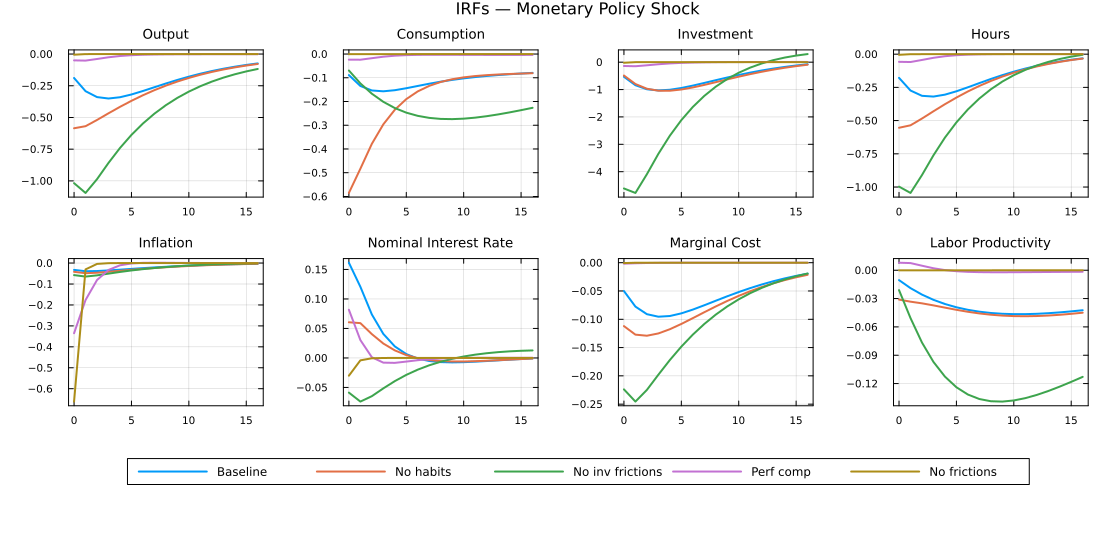

In [12]:
PlotIRFs(
    [sol, sol_nohabits, sol_noinv_fric, sol_perfcomp, sol_nofrictions],
    labels     = ["Baseline", "No habits", "No inv frictions", "Perf comp", "No frictions"],
    shock      = 1,
    shock_name = "Monetary Policy"
)

### 7.2 Technology Shock

A positive neutral technology shock raises productivity permanently (it is a shock to the **growth rate** of technology, so it permanently shifts the level of TFP). In the baseline model, output and consumption rise persistently. The response of hours is theoretically ambiguous — with flexible prices, households can afford more leisure and hours may fall, but with sticky prices, firms need to expand labor to meet demand.

Note that **level responses** are shown here (growth-rate IRFs cumulated to levels), so the interpretation is the cumulative impact on output, consumption, etc. relative to the pre-shock balanced growth path.

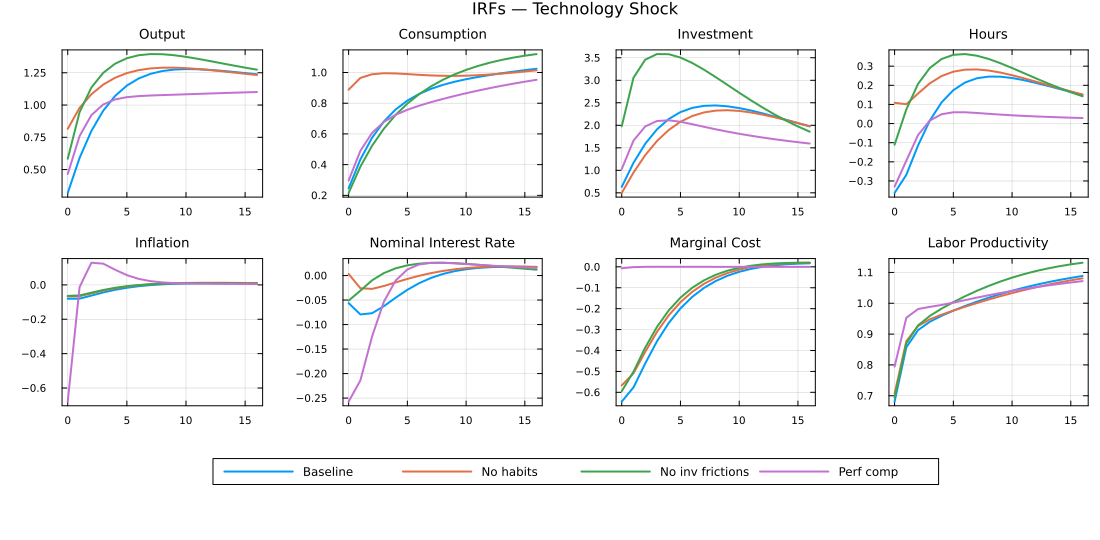

In [11]:
PlotIRFs(
    [sol, sol_nohabits, sol_noinv_fric, sol_perfcomp],
    labels     = ["Baseline", "No habits", "No inv frictions", "Perf comp"],
    shock      = 2,
    shock_name = "Technology"
)

### 7.3 Investment-Specific Technology Shock

The **investment shock** ($\mu_t$) is the central shock in the JPT paper. It represents a disturbance to the **marginal efficiency of transforming consumption goods into installed capital** — equivalently, a change in the relative price of investment goods. A positive shock makes investment cheaper, boosting capital accumulation and output.

Key findings from JPT (2010):
- This shock explains approximately **50–60% of business-cycle fluctuations** in output and hours at business-cycle frequencies.
- **Investment adjustment costs** are crucial: without them (dashed line), the investment response is much larger on impact but does not generate the hump-shaped output response observed in the data.
- **Habit formation** slows the consumption response, contributing to the co-movement of consumption and investment that investment shocks can generate.

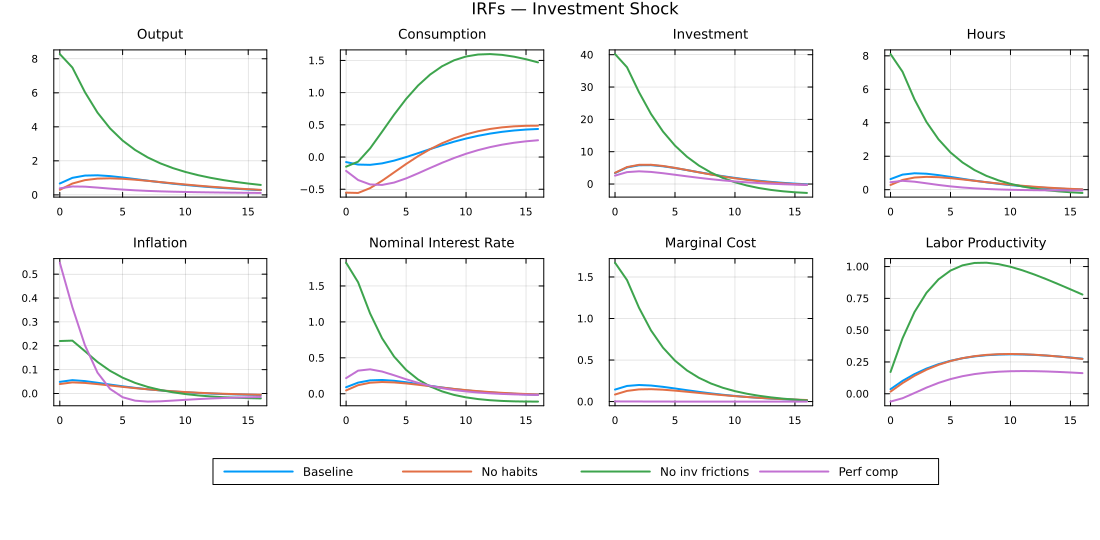

In [10]:
PlotIRFs(
    [sol, sol_nohabits, sol_noinv_fric, sol_perfcomp],
    labels     = ["Baseline", "No habits", "No inv frictions", "Perf comp"],
    shock      = 4,
    shock_name = "Investment"
)
